# Проект. Исследование стартапов

## Введение

Провожу исследование на исторических данных о компаниях, объёмах и типах привлечённых инвестиций, статистикой по возвратам средств с целью выявления закономерности финансирования стартапов и оценки перспективы выхода на рынок с покупкой и развитием компаний.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

### 1.1. Вывод общей информации


In [1]:
# Импортируем библиотеку
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df_investments = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [3]:
df_returns = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv')

In [4]:
df_investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [5]:
df_investments.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


В датафрейме 40 столбцов и 54294 строк. Типы данных представлены float64 (24 столбца) и object (16 столбцов). Из них: 

- Столбец 'funding_total_usd' представлен некорректным типом данных **object**, так как данный столбец отражает объём привлечённых инвестиций, поэтому его можно переделеать в числовой тип данных.
- Столбцы 'founded_at', 'founded_month', 'founded_quarter', 'first_funding_at', 'mid_funding_at', 'last_funding_at' представлен типом данных **object** - можно привести к типу данных даты.
- Во всех столбцах есть пропущенные значения. 
- Все названия столбцов отражают содержимое данных.
- В некоторых названиях столбцов содержатся пробелы.

In [6]:
df_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [7]:
df_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


В датафрейме 14 столбцов и 15 строк. Типы данных представлены float64 (13 столбцов) и int64 (1 столбец).

- В данном датафрейме типы данных установлены правильно.
- Во всех столбцах нет пропущенных значений.
- Все названия столбцов отражают содержимое данных.

### 1.2. Предобработка данных

In [8]:
#Названия столбцов датафрейма df_investments
df_investments.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [9]:
#Удаляем пробелы в названиях столбцов датафрейма df_investments
df_investments.columns = df_investments.columns.str.strip()

In [10]:
#Названия столбцов датафрейма df_returns
df_returns.columns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

In [11]:
#Кол-во пропусков до преобразования
df_investments['funding_total_usd'].isna().sum()

4856

In [12]:
#Убираем разделитель ','
df_investments['funding_total_usd'] = df_investments['funding_total_usd'].str.replace(',', '', regex=False)

In [13]:
#Преобразовать в числовой тип
df_investments['funding_total_usd'] = pd.to_numeric(
    df_investments['funding_total_usd'],
    errors='coerce'
)

In [14]:
#Проверим тип данных
print(df_investments['funding_total_usd'].dtype)

float64


In [15]:
#Проверим значения
print(df_investments['funding_total_usd'].head(30))

0      90000000.0
1       2000000.0
2       9000000.0
3       7700000.0
4        540000.0
5      19000000.0
6      12000000.0
7       8700000.0
8       6000000.0
9       3500000.0
10     28000000.0
11      2705000.0
12      8900000.0
13            NaN
14      8000000.0
15            NaN
16      3900000.0
17    750500000.0
18      2000000.0
19            NaN
20    175000000.0
21      2000000.0
22     15304039.0
23     90000000.0
24       197634.0
25     43500000.0
26      5000000.0
27            NaN
28     13400000.0
29      7700000.0
Name: funding_total_usd, dtype: float64


In [16]:
#Кол-во пропусков после преобразования
df_investments['funding_total_usd'].isna().sum()

13387

- Столбцы 'founded_at', 'founded_month', 'founded_quarter', 'first_funding_at', 'mid_funding_at', 'last_funding_at' представлен типом данных object - можно привести к типу данных даты.

In [17]:
#Приводим столбцы 'founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at' к формату даты и времени
df_investments['founded_at'] = pd.to_datetime(df_investments['founded_at'], errors='coerce')
df_investments['first_funding_at'] = pd.to_datetime(df_investments['first_funding_at'], errors='coerce')
df_investments['mid_funding_at'] = pd.to_datetime(df_investments['mid_funding_at'], errors='coerce')
df_investments['last_funding_at'] = pd.to_datetime(df_investments['last_funding_at'], errors='coerce')

In [18]:
#Приводим столбец 'founded_month' формата YYYY-MM к дате
df_investments['founded_month'] = pd.to_datetime(
    df_investments['founded_month'],
    format='%Y-%m',
    errors='coerce'
)

In [19]:
#Приводим столбец 'founded_quarter' формата YYYY-QN к дате
df_investments['founded_quarter'] = (
    df_investments['founded_quarter']
        .str.replace('Q', '', regex=False)
)

df_investments['founded_quarter'] = pd.to_datetime(
    df_investments['founded_quarter'],
    format='%Y-%m',
    errors='coerce'
)

In [20]:
#Проверка значений типа данных
df_investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  49437 non-null  object        
 1   homepage_url          45989 non-null  object        
 2   category_list         45477 non-null  object        
 3   market                45477 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                48124 non-null  object        
 6   country_code          44165 non-null  object        
 7   state_code            30161 non-null  object        
 8   region                44165 non-null  object        
 9   city                  43322 non-null  object        
 10  funding_rounds        49438 non-null  float64       
 11  participants          30473 non-null  float64       
 12  founded_at            38553 non-null  datetime64[ns]
 13  founded_month   

In [21]:
#Делаем столбец 'year' индексом всего датасета
df_returns = df_returns.set_index('year')

**Проверяем пропуски в датасете df_investments**

In [22]:
#Кол-во пропущенных строк в датасете
df_investments.isna().sum()

name                     4857
homepage_url             8305
category_list            8817
market                   8817
funding_total_usd       13387
status                   6170
country_code            10129
state_code              24133
region                  10129
city                    10972
funding_rounds           4856
participants            23821
founded_at              15741
founded_month           15812
founded_quarter         15812
founded_year            15740
first_funding_at         4866
mid_funding_at          24006
last_funding_at          4862
seed                     4856
venture                  4856
equity_crowdfunding      4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_A                  4856
round_B   

In [23]:
#Процент пропущенных строк
df_investments.isna().sum() / len(df_investments) * 100

name                     8.945740
homepage_url            15.296350
category_list           16.239363
market                  16.239363
funding_total_usd       24.656500
status                  11.364055
country_code            18.655837
state_code              44.448742
region                  18.655837
city                    20.208494
funding_rounds           8.943898
participants            43.874093
founded_at              28.992154
founded_month           29.122923
founded_quarter         29.122923
founded_year            28.990312
first_funding_at         8.962316
mid_funding_at          44.214830
last_funding_at          8.954949
seed                     8.943898
venture                  8.943898
equity_crowdfunding      8.943898
undisclosed              8.943898
convertible_note         8.943898
debt_financing           8.943898
angel                    8.943898
grant                    8.943898
private_equity           8.943898
post_ipo_equity          8.943898
post_ipo_debt 

In [24]:
#Заменяем пропуски в 'name', 'homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city'
object_cols = ['name', 'homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city']
df_investments[object_cols] = df_investments[object_cols].fillna('не указано')

In [25]:
#Проверяем датасет
df_investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  54294 non-null  object        
 1   homepage_url          54294 non-null  object        
 2   category_list         54294 non-null  object        
 3   market                54294 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                54294 non-null  object        
 6   country_code          54294 non-null  object        
 7   state_code            54294 non-null  object        
 8   region                54294 non-null  object        
 9   city                  54294 non-null  object        
 10  funding_rounds        49438 non-null  float64       
 11  participants          30473 non-null  float64       
 12  founded_at            38553 non-null  datetime64[ns]
 13  founded_month   

In [26]:
#Проверяем кол-во пропущенных строк в датасете
df_investments.isna().sum()

name                        0
homepage_url                0
category_list               0
market                      0
funding_total_usd       13387
status                      0
country_code                0
state_code                  0
region                      0
city                        0
funding_rounds           4856
participants            23821
founded_at              15741
founded_month           15812
founded_quarter         15812
founded_year            15740
first_funding_at         4866
mid_funding_at          24006
last_funding_at          4862
seed                     4856
venture                  4856
equity_crowdfunding      4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_A                  4856
round_B   

**Проверяем пропуски в датасете df_returns**

In [27]:
#Кол-во пропущенных строк в датасете
df_returns.isna().sum()

seed                    0
venture                 0
equity_crowdfunding     0
undisclosed             0
convertible_note        0
debt_financing          0
angel                   0
grant                   0
private_equity          0
post_ipo_equity         0
post_ipo_debt           0
secondary_market        0
product_crowdfunding    0
dtype: int64

In [28]:
#Полные дубликаты в данных датасета df_investments
df_investments.duplicated().sum()

4855

In [29]:
#Полные дубликаты в данных датасета df_returns
df_returns.duplicated().sum()

0

In [30]:
#Нормализация данных в столбце 'name' и 'market'
df_investments['name'] = df_investments['name'].str.lower().str.strip()
df_investments['market'] = df_investments['market'].str.lower().str.strip()

In [31]:
#Перепроверяем полные дубликаты в данных датасета df_investments
df_investments.duplicated().sum()

4855

In [32]:
#Удаляем полные дубликаты
df_investments = df_investments.drop_duplicates()

In [33]:
#Проверяем
df_investments.duplicated().sum()

0

In [34]:
#Обработайтываем пропуски в funding_total_usd

#Удаляем строки без информации
df_investments = df_investments.dropna(subset=['funding_total_usd'])

#Удаляем 0 значение, так как оно не несет информации
df_investments = df_investments[df_investments['funding_total_usd'] > 0]

In [35]:
#Заполняем пропуски в mid_funding_at
df_investments['mid_funding_at'] = df_investments['mid_funding_at'].fillna(df_investments['first_funding_at'] + (df_investments['last_funding_at'] - df_investments['first_funding_at'])/2)

In [36]:
df_investments.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40907 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40907 non-null  object        
 1   homepage_url          40907 non-null  object        
 2   category_list         40907 non-null  object        
 3   market                40907 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                40907 non-null  object        
 6   country_code          40907 non-null  object        
 7   state_code            40907 non-null  object        
 8   region                40907 non-null  object        
 9   city                  40907 non-null  object        
 10  funding_rounds        40907 non-null  float64       
 11  participants          27331 non-null  float64       
 12  founded_at            32200 non-null  datetime64[ns]
 13  founded_month   

Для работы над проектом предоставлено 2 датафрейма: 
- df_investments - Содержит информацию о компаниях и состоявшемся финансировании
- df_returns - Содержит информацию об объёмах возвратов по годам и типам финансирования в миллионах долларов
- Кол-во строк в датафрейме df_investments до обработки данных - 54294. Кол-во строк после - 40907. Процент отброшенных данных - 24,7% 
- Кол-во строк в датафрейме df_returns до и после обработки данных не поменялось. 

На этапе предобработки данных:
- Проведена нормализация названий столбцов 
- В столбце funding_total_usd выделены разряды и приведены к числовому типу
- Столбцы 'founded_at', 'founded_month', 'founded_quarter', 'first_funding_at', 'mid_funding_at', 'last_funding_at' приведены к типу данных даты и времени.
- Обработаны текстовые данные. Пропуски в текстовых столбцах заполнены заглушками.
- Обработаны полные дубликаты в данных и пропуски в funding_total_usd. Убраны строк, которые не содержат данных о финансировании.
- Заполнены пропуски в значениях mid_funding_at на основании значений в столбцах first_funding_at и last_funding_at.

Для решения задач данных достаточно. 

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Разделение всех компаний на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализация соотношения этих групп, используя два графика:

* По количеству компаний: какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: какую долю от общего объёма привлечённых средств получила каждая группа.


In [37]:
#Расчитываем длительность финансирования
df_investments['funding_duration_days'] = (
    df_investments['last_funding_at'] - df_investments['first_funding_at']
).dt.days

In [38]:
#Категории

conditions = [
    df_investments['funding_duration_days'] == 0,
    df_investments['funding_duration_days'] <= 365,
    df_investments['funding_duration_days'] > 365
]

choices = [
    'Единичное финансирование',
    'До года',
    'Более года'
]

df_investments['funding_group'] = np.select(conditions, choices, default='Без данных')

print(df_investments['funding_group'])

0        Единичное финансирование
1        Единичное финансирование
2        Единичное финансирование
3                         До года
4        Единичное финансирование
                   ...           
49433    Единичное финансирование
49434    Единичное финансирование
49435    Единичное финансирование
49436    Единичное финансирование
49437    Единичное финансирование
Name: funding_group, Length: 40907, dtype: object


In [39]:
#Для создания одинакового цвета на графиках
all_groups = sorted(df_investments['funding_group'].unique())

base_colors = plt.cm.tab10.colors

color_dict = {
    group: base_colors[i % len(base_colors)]
    for i, group in enumerate(all_groups)
}

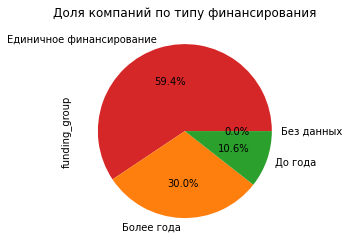

In [40]:
#График по количеству компаний
company_share = (
    df_investments['funding_group']
    .value_counts(normalize=True) * 100
)

colors1 = [color_dict[g] for g in company_share.index]

company_share.plot(kind='pie', autopct='%1.1f%%', colors=colors1)
plt.title('Доля компаний по типу финансирования')

plt.show()

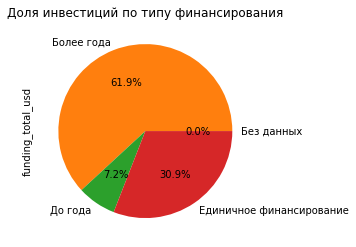

In [41]:
#График по объёму инвестиций
investment_share = (
    df_investments.groupby('funding_group')['funding_total_usd']
      .sum()
)

investment_share = investment_share / investment_share.sum() * 100

colors2 = [color_dict[g] for g in investment_share.index]

investment_share.plot(kind='pie', autopct='%1.1f%%', colors=colors2)
plt.title('Доля инвестиций по типу финансирования')

plt.show()

- По кол-ву компаний: 59,4% - единичное финансирование, 30% - более года, 10,6% - до года.
- По кол-ву инвестиций: 61.9% - более года, 30,9% - единичное финансирование, 7,2% - до года.

### 2.2 Выделение средних и нишевых сегментов рынка

In [42]:
#Кол-во компаний в сегментах
market_counts = df_investments['market'].value_counts()

#Классификация
def segment_type(x):
    if x > 120:
        return 'Массовый'
    elif 35 <= x <= 120:
        return 'Средний'
    else:
        return 'Нишевый'

segment_categories = market_counts.apply(segment_type)

#Кол-во сегментов в каждой категории
category_counts = segment_categories.value_counts()

print(category_counts)

Нишевый     289
Средний      57
Массовый     49
Name: market, dtype: int64


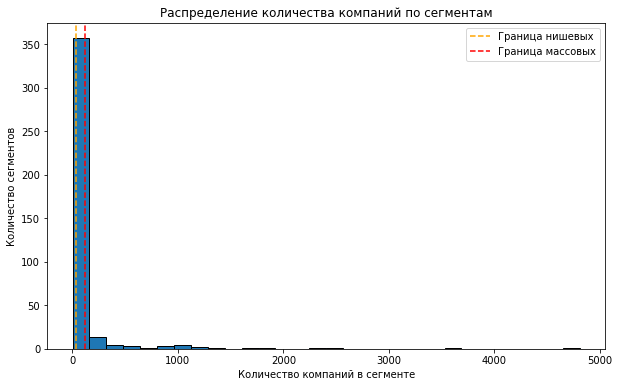

In [43]:
plt.figure(figsize=(10,6))

plt.hist(market_counts, bins=30, edgecolor='black')

plt.axvline(35, color='orange', linestyle='--', label='Граница нишевых')
plt.axvline(120, color='red', linestyle='--', label='Граница массовых')

plt.title('Распределение количества компаний по сегментам')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов')
plt.legend()

plt.show()

In [44]:
def segments_new(x):
    count = market_counts.get(x, 0)
    if count > 120:
        return x
    elif 35 <= count <= 120:
        return 'mid'
    else:
        return 'niche'

df_investments['market'] = df_investments['market'].apply(segments_new)

df_investments['market'].value_counts()

software                4812
mid                     3841
biotechnology           3590
не указано              2503
mobile                  2344
e-commerce              1866
curated web             1693
enterprise software     1381
health care             1185
clean technology        1180
games                   1117
advertising             1107
hardware + software     1062
social media            1003
health and wellness      873
education                844
niche                    830
finance                  828
analytics                667
manufacturing            596
security                 567
semiconductors           484
web hosting              424
consulting               349
hospitality              336
travel                   330
fashion                  303
news                     301
messaging                295
search                   291
real estate              279
saas                     272
music                    264
internet                 241
technology    

- Категория - mid — 5069 компаний (это объединённая группа всех средних сегментов, по числу компаний)
- Категория niche — 2494 компании (объединённые нишевые сегменты)
- Массовый сегмент — компании варьируются по числу компаний от 133 до 4812. Массовый сегмент показывает, где рынок наиболее развит и есть большое количество компаний с типичным финансированием.
- Наибольшие компании в массовом сегменте:
  - Software — 4812
  - Biotechnology — 3590
  - Mobile — 2344

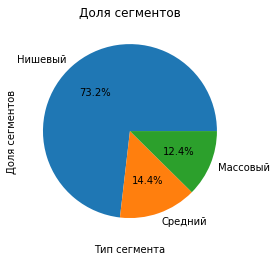

In [45]:
#Доля сегментов
segment_categories.value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%')

plt.title('Доля сегментов')
plt.xlabel('Тип сегмента')
plt.ylabel('Доля сегментов')
plt.show()

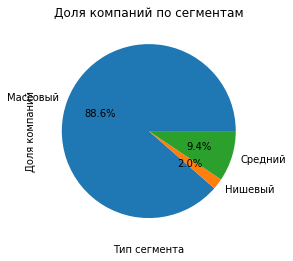

In [46]:
#Доля компаний
companies_by_type = market_counts.groupby(segment_categories).sum()

companies_by_type.div(companies_by_type.sum()).plot(kind='pie', autopct='%1.1f%%')

plt.title('Доля компаний по сегментам')
plt.xlabel('Тип сегмента')
plt.ylabel('Доля компаний')
plt.show()

- Большая часть сегментов относится к нишевым (73.2%) - рынок стартапов включает большое количество узких направлений, в которых работает относительно небольшое число компаний.
- Однако основная доля компаний сосредоточена в массовом сегменте (88.6%) - большинство стартапов стремится работать в уже сформировавшихся и популярных направлениях рынка, где выше спрос, больше инвестиций и лучше развита инфраструктура.
- Нишевые сегменты позволяют тестировать новые идеи и технологии с меньшей конкуренцией. Многие инновации появляются именно в таких узких направлениях.
- Массовые сегменты концентрируют большое количество компаний, инвестиций и клиентов, что ускоряет развитие технологий и формирование устойчивых бизнес-моделей.
- Нишевые сегменты могут со временем вырасти в массовые, если технология или продукт становится востребованным.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

По столбцу `funding_total_usd` оцениваем, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. 

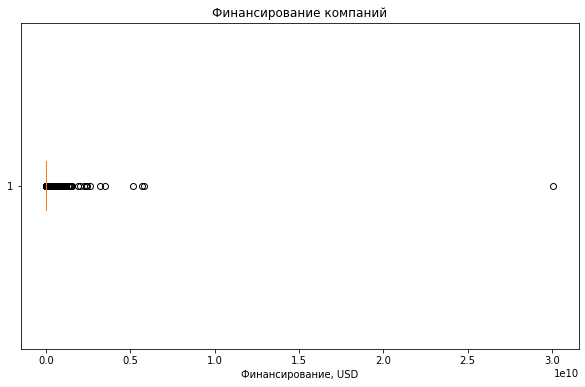

In [47]:
plt.figure(figsize=(10,6))

plt.boxplot(df_investments['funding_total_usd'], vert=False)
plt.title('Финансирование компаний')
plt.xlabel('Финансирование, USD')
plt.show()

In [48]:
df_investments['funding_total_usd'].describe()

count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

In [49]:
Q1 = df_investments['funding_total_usd'].quantile(0.25)
Q3 = df_investments['funding_total_usd'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Типичные значения финансирования лежат примерно между {lower_bound:,.0f} и {upper_bound:,.0f} USD")

Типичные значения финансирования лежат примерно между -14,125,000 и 24,475,000 USD


- Распределение финансированият асимметричное, скошенное вправо. 
- Всё, что выше 75 процентиля — выбросы (очень крупные инвестиции)
- Всё, что ниже 25 процентиля — выбросы (очень маленькие инвестиции)
- Типичные значения финансирования лежат примерно между -14,125,000 и 24,475,000 USD

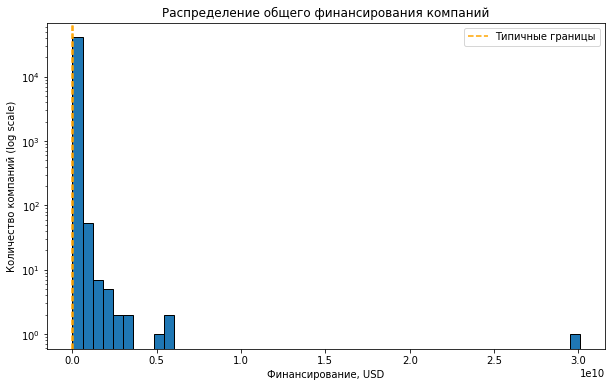

In [50]:
plt.figure(figsize=(10,6))
plt.hist(df_investments['funding_total_usd'], bins=50, edgecolor='black', log=True)
plt.axvline(lower_bound, color='orange', linestyle='--', label='Типичные границы')
plt.axvline(upper_bound, color='orange', linestyle='--')
plt.title('Распределение общего финансирования компаний')
plt.xlabel('Финансирование, USD')
plt.ylabel('Количество компаний (log scale)')
plt.legend()
plt.show()

In [51]:
# Столбец для аномальных значений
df_investments['is_outlier'] = False

# Перебираем сегменты
for segment, group in df_investments.groupby('market'):
    Q1 = group['funding_total_usd'].quantile(0.25)
    Q3 = group['funding_total_usd'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Флагируем выбросы
    df_investments.loc[group.index, 'is_outlier'] = (
        (group['funding_total_usd'] < lower_bound) | 
        (group['funding_total_usd'] > upper_bound)
    )
    
#df_investments['is_outlier'] = True для компаний с аномальным финансированием в пределах своего сегмента.

In [52]:
# Считаем долю выбросов по каждому сегменту
outlier_ratio = df_investments.groupby('market')['is_outlier'].mean() * 100  # в процентах
print(outlier_ratio.sort_values(ascending=False))

market
real estate             17.204301
entertainment           16.666667
consulting              16.618911
search                  16.494845
cloud computing         16.447368
photography             16.176471
saas                    16.176471
technology              15.966387
video                   15.957447
niche                   15.903614
travel                  15.454545
networking              15.384615
internet                15.352697
big data                15.333333
marketplaces            15.306122
не указано              14.902117
mid                     14.475397
e-commerce              14.415863
apps                    14.349776
automotive              14.193548
medical                 13.907285
sports                  13.725490
social media            13.559322
news                    13.289037
education               13.270142
fashion                 13.201320
mobile                  13.182594
hospitality             13.095238
health and wellness     12.943872
messagi

In [53]:
#Топ сегментов
top_outlier_segments = outlier_ratio.sort_values(ascending=False)
print(top_outlier_segments.head(10))

market
real estate        17.204301
entertainment      16.666667
consulting         16.618911
search             16.494845
cloud computing    16.447368
photography        16.176471
saas               16.176471
technology         15.966387
video              15.957447
niche              15.903614
Name: is_outlier, dtype: float64


- Доля компаний с аномальным финансированием варьируется примерно от 7 % до 17 %.
- Верхняя часть списка (15–17 %) — сегменты с наибольшей долей выбросов, нижняя часть (7–14 %) — с наименьшей.
- В Топ-10 сегментов по выбросам вошли компании, которые получают очень крупные или очень маленькие инвестиции по сравнению с типичным значением для сегмента.
- Сегменты с наименьшей долей выбросов: Semiconductors (7 %), Nonprofits (9,6 %) и Web Hosting (10,1 %). Они относительно равномерно финансируются, экстремальные значения встречаются реже.
- Нишевые и средние сегменты показывают умеренную долю выбросов (15,9% и 14,5% соответственно) — экстремальные значения есть, но это не критично.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии


In [54]:
#Данные за 2014 год
df_2014 = df_investments[df_investments['mid_funding_at'].dt.year == 2014]

#Диапазон дат
print(df_2014['mid_funding_at'].min())
print(df_2014['mid_funding_at'].max())

#Проверка месяцев
months_2014 = sorted(df_2014['mid_funding_at'].dt.month.unique())
print(months_2014)

2014-01-01 00:00:00
2014-12-31 00:00:00
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


- Можно считать, что предоставлены полные данные за 2014 год.

In [55]:
#Исключаем компании с аномальным финансированием
df_clean_investments = df_investments[~df_investments['is_outlier']].copy()

In [56]:
#Считаем кол-во раундов по годам
df_clean_investments['year'] = df_clean_investments['mid_funding_at'].dt.year
rounds_by_year = df_clean_investments.groupby('year')['funding_rounds'].sum()

In [57]:
#Годы, где больше 50 раундов
years_50 = rounds_by_year[rounds_by_year >= 50].index
print(years_50)

Float64Index([2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0,
              2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0],
             dtype='float64', name='year')


In [58]:
#Компании
company_50 = df_clean_investments[df_clean_investments['year'].isin(years_50)]
print(company_50)

                                  name              homepage_url  \
1          university of new brunswick         http://www.unb.ca   
2                               dupont     http://www.dupont.com   
3               university of michigan     http://www.umich.edu/   
4      case western reserve university       http://www.case.edu   
7                      duke university       http://www.duke.edu   
...                                ...                       ...   
49430                           grid4c         http://grid4c.com   
49433                      riversilica    http://riversilica.com   
49434              southgobi resources      http://southgobi.com   
49435                         digibyte        http://digibyte.co   
49437                         logovers  http://www.logovers.com/   

                                           category_list      market  \
1                                             не указано  не указано   
2      |Business Services|Agriculture|A

In [59]:
company_50.shape

(35588, 44)

In [60]:
#Отфильтрованный датасет
df_clean_investments = df_clean_investments[
    df_clean_investments['year'].isin(years_50)
]

- После исключения компаний с аномальным финансированием были определены годы, в которые происходило 50 и более раундов финансирования - с 2000 по 2014 год
- Данные предоставлены за полный 2014 год.
- Кол-во компаний, которые получили финансирование в эти годы - 35629

### 3.3. Анализ типов финансирования по объёму и популярности



In [61]:
#Список столбцов с типами финансирования
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

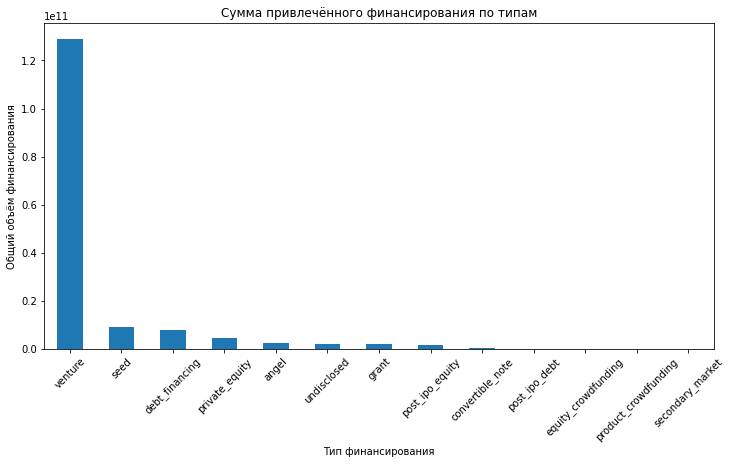

In [62]:
#Типы финансирования, которые привлекли больше всего денег
funding_sum = df_clean_investments[funding_types].sum().sort_values(ascending=False)

funding_sum.plot(kind='bar', figsize=(12,6))

plt.title('Сумма привлечённого финансирования по типам')
plt.ylabel('Общий объём финансирования')
plt.xlabel('Тип финансирования')

plt.xticks(rotation=45)
plt.show()

- Типы финансирования, которые привлекли больше всего денег: venture, seed, debt_financing.

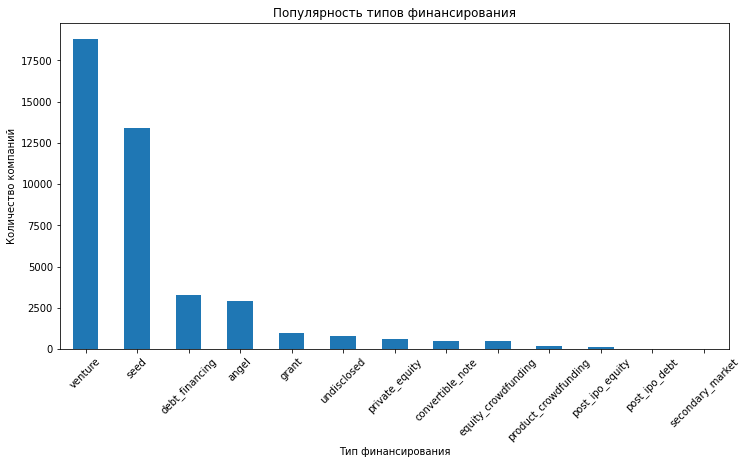

In [63]:
#Популярность типов финансирования
funding_count = (df_clean_investments[funding_types] > 0).sum().sort_values(ascending=False)

funding_count.plot(kind='bar', figsize=(12,6))

plt.title('Популярность типов финансирования')
plt.ylabel('Количество компаний')
plt.xlabel('Тип финансирования')

plt.xticks(rotation=45)
plt.show()

- Самые популярные типы финансирования: venture, seed, debt_financing.

- В топ-3 по привлечению финансирования и по популярности вышли одни и те же типы финансирования: venture, seed, debt_financing.
- Тип финансирования venture значительно выделяется по типу привлеченного финансирования. Также он находится на первом месте и по популярности. 

In [64]:
#Список столбцов с типами финансирования
funding_types2 = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

In [65]:
#Суммарные возвраты за весь период
returns_sum = df_returns[funding_types2].sum().sort_values(ascending=False)

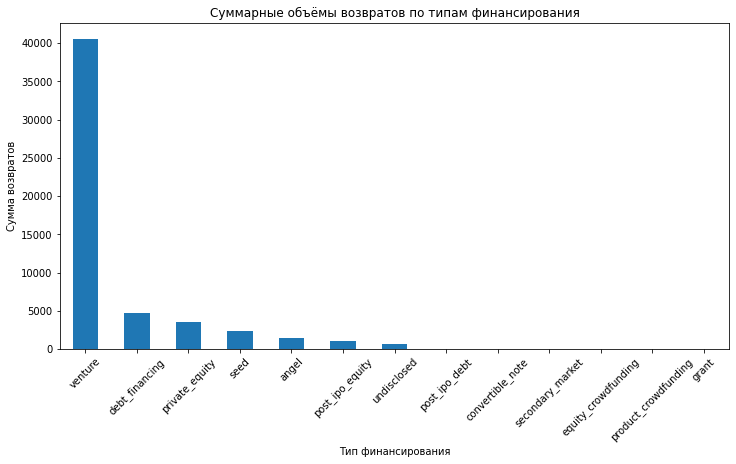

In [66]:
plt.figure(figsize=(12,6))

returns_sum.plot(kind='bar')

plt.title('Суммарные объёмы возвратов по типам финансирования')
plt.xlabel('Тип финансирования')
plt.ylabel('Сумма возвратов')
plt.xticks(rotation=45)

plt.show()

- Самый большой объём возвратов в типах финансирования: venture, debt_financing, private_equity

- Venture лидирует по объёму инвестиций и возвратности, обеспечивая масштабирование и прибыльность для инвесторов. 
- Seed и Angel популярны на ранних стадиях — они позволяют множеству стартапов получать стартовый капитал, хотя суммы и возвраты относительно невелики. 
- Debt и альтернативные формы финансирования применяются реже, но обеспечивают стабильность и дополнительные возможности для зрелых или специфических проектов.
- Таким образом, мы видим, что venture обеспечивает основной объём инвестиций и максимальные возвраты, seed и angel популярны для старта новых проектов, а долговое и альтернативное финансирование поддерживает зрелые и инновационные компании.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам



In [67]:
#Средний объём одного раунда для компании:
df_clean_investments['avg_funding_per_round'] = df_clean_investments['funding_total_usd'] / df_clean_investments['funding_rounds']

In [68]:
#Группируем по годам
avg_per_round_by_year = df_clean_investments.groupby('year')['avg_funding_per_round'].mean()
print(avg_per_round_by_year)

year
2000.0    4.492723e+06
2001.0    3.366817e+06
2002.0    4.053461e+06
2003.0    3.099490e+06
2004.0    4.616702e+06
2005.0    5.801089e+06
2006.0    5.346925e+06
2007.0    4.678782e+06
2008.0    4.322739e+06
2009.0    3.517328e+06
2010.0    3.188317e+06
2011.0    2.598416e+06
2012.0    2.035770e+06
2013.0    1.976610e+06
2014.0    2.203065e+06
Name: avg_funding_per_round, dtype: float64


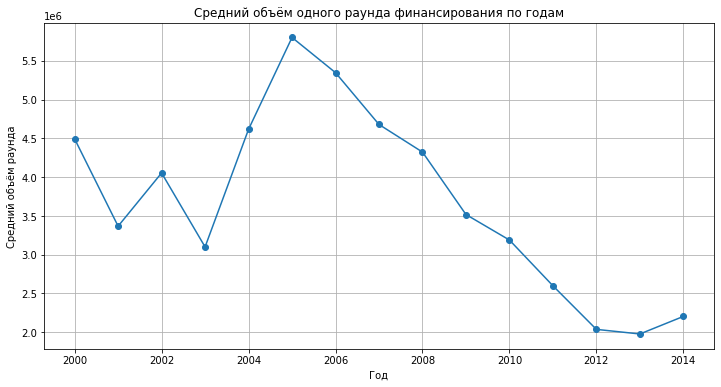

In [69]:
plt.figure(figsize=(12,6))
avg_per_round_by_year.plot(marker='o')

plt.title('Средний объём одного раунда финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Средний объём раунда')
plt.grid(True)
plt.show()

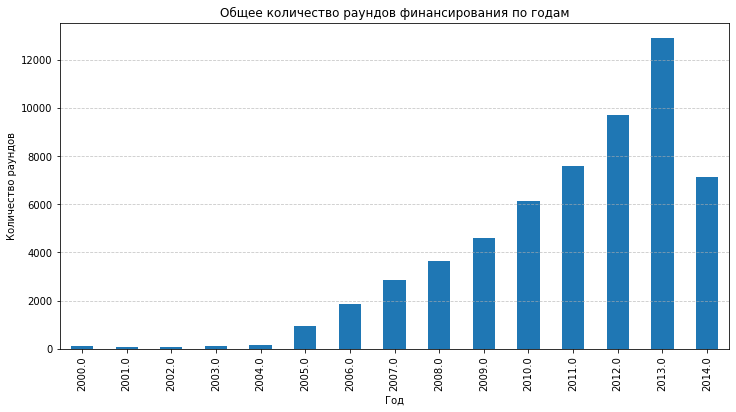

In [70]:
#Годовая динамика общего количества раундов
total_rounds_by_year = df_clean_investments.groupby('year')['funding_rounds'].sum()

plt.figure(figsize=(12,6))
total_rounds_by_year.plot(kind='bar')

plt.title('Общее количество раундов финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Количество раундов')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

- Типичный размер средств, собранных в рамках одного раунда, был максимальным в 2005 году.
- В 2014 году наблюдается снижение кол-ва раундов - значит был более низкий интерес инвесторов. При этом средний объем финансирования в 2014 году имел небольшую положительную данамику в сравнении с 2012 и 2013г, после отрицательной динамики, начиная с 2006г.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов



In [71]:
#Сводная таблица
pivot = df_clean_investments.pivot_table(
    index='year',
    columns='market', 
    values='funding_total_usd',
    aggfunc='sum'
)
print(pivot)

market  advertising    analytics        apps   automotive    big data  \
year                                                                    
2000.0   14470000.0   14822803.0         NaN          NaN         NaN   
2001.0    8778321.0          NaN         NaN          NaN         NaN   
2002.0   24500000.0    7500000.0         NaN          NaN         NaN   
2003.0   10500000.0    3840000.0         NaN    4530000.0         NaN   
2004.0    6000000.0    3000000.0         NaN          NaN         NaN   
2005.0  127196022.0   79014044.0         NaN   22500000.0         NaN   
2006.0  299299458.0  139701311.0   1310600.0   12660000.0         NaN   
2007.0  556704331.0   98829000.0         NaN   37712601.0   7780000.0   
2008.0  622673464.0  208077840.0   4300000.0   59478635.0   2452515.0   
2009.0  563446005.0  140949327.0   7219000.0   20800311.0    597375.0   
2010.0  631617869.0  253739903.0   6123779.0   17696916.0  39233297.0   
2011.0  410730737.0  443333373.0  18374071.0   7645

In [72]:
#Сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013
growth_2014 = pivot.loc[2014] > pivot.loc[2013]
pivot_growth = pivot.loc[:, growth_2014]
print(pivot_growth)

market        apps    big data      design     internet  manufacturing  \
year                                                                     
2000.0         NaN         NaN         NaN   10000000.0     56659310.0   
2001.0         NaN         NaN         NaN          NaN      2368582.0   
2002.0         NaN         NaN         NaN    1100000.0            NaN   
2003.0         NaN         NaN         NaN          NaN      4269608.0   
2004.0         NaN         NaN         NaN   10500000.0      3000000.0   
2005.0         NaN         NaN   9300000.0    1775000.0     61770000.0   
2006.0   1310600.0         NaN    707000.0       5000.0    163957751.0   
2007.0         NaN   7780000.0  10800000.0    4495379.0    147726051.0   
2008.0   4300000.0   2452515.0   5944302.0   23412964.0    173054260.0   
2009.0   7219000.0    597375.0   2150144.0   38195773.0    422862531.0   
2010.0   6123779.0  39233297.0  17239975.0   36657500.0    244329661.0   
2011.0  18374071.0  60369158.0   88999

In [73]:
#Исключаем сегменты mid и niche
mass_df = df_clean_investments[~df_clean_investments['market'].isin(['mid', 'niche'])]

#Сводная таблица
pivot = mass_df.pivot_table(
    index='year',
    columns='market',
    values='funding_total_usd',
    aggfunc='sum'
)

print(pivot)

market  advertising    analytics        apps   automotive    big data  \
year                                                                    
2000.0   14470000.0   14822803.0         NaN          NaN         NaN   
2001.0    8778321.0          NaN         NaN          NaN         NaN   
2002.0   24500000.0    7500000.0         NaN          NaN         NaN   
2003.0   10500000.0    3840000.0         NaN    4530000.0         NaN   
2004.0    6000000.0    3000000.0         NaN          NaN         NaN   
2005.0  127196022.0   79014044.0         NaN   22500000.0         NaN   
2006.0  299299458.0  139701311.0   1310600.0   12660000.0         NaN   
2007.0  556704331.0   98829000.0         NaN   37712601.0   7780000.0   
2008.0  622673464.0  208077840.0   4300000.0   59478635.0   2452515.0   
2009.0  563446005.0  140949327.0   7219000.0   20800311.0    597375.0   
2010.0  631617869.0  253739903.0   6123779.0   17696916.0  39233297.0   
2011.0  410730737.0  443333373.0  18374071.0   7645

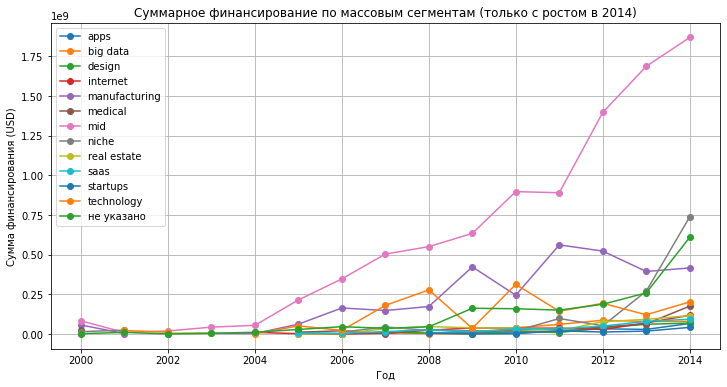

In [74]:
plt.figure(figsize=(12,6))

for segment in pivot_growth.columns:
    plt.plot(pivot_growth.index, pivot_growth[segment], marker='o', label=segment)

plt.title('Суммарное финансирование по массовым сегментам (только с ростом в 2014)')
plt.xlabel('Год')
plt.ylabel('Сумма финансирования (USD)')
plt.legend()
plt.grid(True)
plt.show()

- На графике видно, что сегмент Design демонстрирует наиболее быстрый и уверенный рост - это тот сегмент, который представляет наиболее привлекательное направление для инвестиций.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

In [80]:
#Суммарное финансирование по годам
funding_sum = df_clean_investments.groupby('year')[funding_types].sum()

#Суммарный вовзрат по годам
returns_sum = df_returns.groupby('year')[funding_types].sum()

returns_mln = returns_sum * 1e6

#Доля возврата
normalized_returns = returns_mln / (funding_sum + 1e-60)

In [81]:
print(normalized_returns)

          seed   venture  equity_crowdfunding  undisclosed  convertible_note  \
year                                                                           
2000  0.996471  0.168922         0.000000e+00     0.697042      0.000000e+00   
2001  1.079592  0.107991         0.000000e+00     0.587483      6.666667e-03   
2002  0.629707  0.682282         0.000000e+00     0.608878      2.000000e+64   
2003  0.505276  0.628260         0.000000e+00     0.914397      1.000000e+64   
2004  0.548476  0.837009         0.000000e+00     0.527559      1.000000e+64   
2005  0.674695  0.546586         0.000000e+00     1.071992      2.000000e+64   
2006  0.925372  0.343678         2.036317e-01     0.759438      1.663181e-01   
2007  0.366153  0.297243         1.000000e+64     0.504971      2.280972e-01   
2008  0.297083  0.190873         3.000000e+64     0.342060      5.978832e-02   
2009  0.563423  0.169517         8.781897e-02     0.376177      5.453492e-02   
2010  0.526648  0.198810         5.27027

In [82]:
# Заменяем доли > 1 или <0 на NaN
normalized_returns = normalized_returns.mask((normalized_returns > 1) | (normalized_returns < 0))
print(normalized_returns)

          seed   venture  equity_crowdfunding  undisclosed  convertible_note  \
year                                                                           
2000  0.996471  0.168922             0.000000     0.697042          0.000000   
2001       NaN  0.107991             0.000000     0.587483          0.006667   
2002  0.629707  0.682282             0.000000     0.608878               NaN   
2003  0.505276  0.628260             0.000000     0.914397               NaN   
2004  0.548476  0.837009             0.000000     0.527559               NaN   
2005  0.674695  0.546586             0.000000          NaN               NaN   
2006  0.925372  0.343678             0.203632     0.759438          0.166318   
2007  0.366153  0.297243                  NaN     0.504971          0.228097   
2008  0.297083  0.190873                  NaN     0.342060          0.059788   
2009  0.563423  0.169517             0.087819     0.376177          0.054535   
2010  0.526648  0.198810             0.0

In [83]:
#Выбираем типы
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

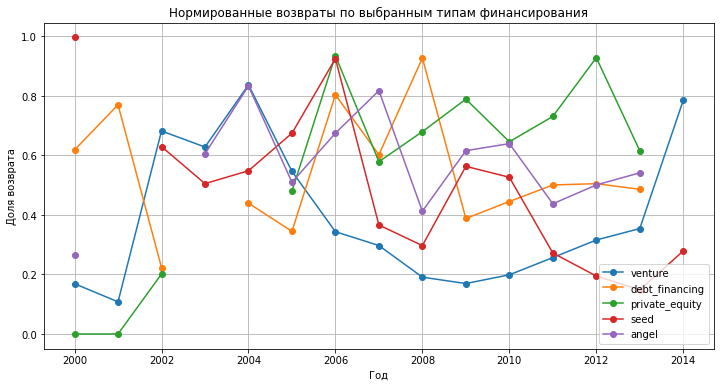

In [84]:
plt.figure(figsize=(12,6))

for col in selected_types:
    plt.plot(normalized_returns.index, normalized_returns[col], marker='o', label=col)

plt.title('Нормированные возвраты по выбранным типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возврата')
plt.legend()
plt.grid(True)
plt.show()

- Наиболее устойчивый рост доли возвратов наблюдается в венчурных инвестициях (venture), они показывают стабильный рост с 2009г, после падения с 2004 по 2009г. 
- Частные инвестиции (private_equity) дают умеренный, стабильный возврат. 
- Долговое финансирование (debt_financing) и инвестиции от бизнес-ангелов (angel) показывают стабильные колебания показателей из года в год, также с подъемом доли возврата в 2014г.
- Самая низкая доля возвратов в инвестициях на посевной стадии (seed) - стабильное падение показателей с 2009г, что говорит о снижении прибыльности со временем, с небольшим подъхемом доли возвратов в 2014г. 



- Рост или снижение доли возвратов не обязательно означает прямое увеличение или снижение эффективности типа финансирования. Это скорее индикатор текущих трендов и рисков. 


## Шаг 5. Итоговый вывод и рекомендации

**Рекомендации:**
- Отрасль для инвестиций
  - сегменты Entertaiment и Internet демонстрируют наиболее быстрый и уверенный рост - это те сегменты, которые представляют наиболее привлекательные направления для инвестиций.

Рекомендация:
Инвестировать в сегменты Entertaiment и Internet, так как они демонстрируют быстрый и уверенный рост, высокую активность рынка и привлекают значительные средства.

- Тип финансирования
  - private_equity показывают устойчивый рост нормированных возвратов и обеспечивает крупные суммы возвратов инвесторам.
  - seed - самая низкая доля возвратов - рискованный, возвраты менее предсказуемы - этот тип не рекомендуется.

Рекомендация:
Использовать частные инвестиции (private equity), так как они обеспечивают стабильные возвраты и позволяют участвовать в крупных раундах для развивающихся компаний.

**Итоги проекта:**

- Выделены группы по срокам финансирования (единичное, до года, более года)
- Выделены массовые, средние и нишевые сегменты.
- Исключены компании с аномальным финансированием.
- Оставлены только годы с 50+ раундами финансирования.
- Проанализщированны типы финансирования по объёму и популярности.
- Выявлен тип с устойчивым ростом (private_equity).
- Рассчитан средний объём одного раунда для каждой компании.
- Составлена сводная таблица суммарного финансирования по годам и сегментам.
- Отобраны сегменты с ростом финансирования в 2014 году для дальнейшего анализа.
- Рассчитаны нормированные значения возврата для каждого типа финансирования (доля возвращённых средств от предоставленных).


1. Выделены группы по срокам финансирования
  - По кол-ву компаний: 59,4% - единичное финансирование, 30% - более года, 10,6% - до года.
  - По кол-ву инвестиций: 61.9% - более года, 30,9% - единичное финансирование, 7,2% - до года.
2. Выделены массовые, средние и нишевые сегменты
  - Категория - mid — 5069 компаний (это объединённая группа всех средних сегментов, по числу компаний)
  - Категория niche — 2494 компании (объединённые нишевые сегменты)
  - Массовый сегмент — компании варьируются по числу компаний от 133 до 4812. Массовый сегмент показывает, где рынок наиболее развит и есть большое количество компаний с типичным финансированием.
  - Наибольшие компании в массовом сегменте:
    - Software — 4812
    - Biotechnology — 3590
    - Mobile — 2344
3. Выявлены выбросы
  - Доля компаний с аномальным финансированием варьируется примерно от 7 % до 17 %.
  - Верхняя часть списка (15–17 %) — сегменты с наибольшей долей выбросов, нижняя часть (7–14 %) — с наименьшей.
  - В Топ-10 сегментов по выбросам вошли компании, которые получают очень крупные или очень маленькие инвестиции по сравнению с типичным значением для сегмента.
  - Сегменты с наименьшей долей выбросов: Semiconductors (7 %), Nonprofits (9,6 %) и Web Hosting (10,1 %). Они относительно равномерно финансируются, экстремальные значения встречаются реже.
  - Нишевые и средние сегменты показывают умеренную долю выбросов (15,9% и 14,5% соответственно) — экстремальные значения есть, но это не критично.
4. Определены границы рассматриваемого периода, отброшены аномалии
  - После исключения компаний с аномальным финансированием были определены годы, в которые происходило 50 и более раундов финансирования - с 2000 по 2014 год
  - Данные предоставлены за полный 2014 год.
  - Кол-во компаний, которые получили финансирование в эти годы - 35629
5. Проанализированны типы финансирования по объёму и популярности
  - Типы финансирования, которые привлекли больше всего денег: venture, seed, debt_financing.
  - Самые популярные типы финансирования: venture, seed, debt_financing.
  - В топ-3 по привлечению финансирования и по популярности вышли одни и те же типы финансирования: venture, seed, debt_financing.
  - Тип финансирования venture значительно выделяется по типу привлеченного финансирования. Также он находится на первом месте и по популярности.
6. Проанализированна динамика предоставления финансирования по годам
  - Типичный размер средств, собранных в рамках одного раунда, был максимальным в 2005 году.
  - В 2014 году наблюдается снижение кол-ва раундов - значит был более низкий интерес инвесторов. При этом средний объем финансирования в 2014 году имел небольшую положительную данамику в сравнении с 2012 и 2013г, после отрицательной динамики, начиная с 2006г.
7. Проанализированна динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов
  - Cегмент Design демонстрирует наиболее быстрый и уверенный рост - это тот сегмент, который представляет наиболее привлекательное направление для инвестиций.
8. Проанализирована годовая динамика доли возвращённых средств по типам финансирования
  - Наиболее устойчивый рост доли возвратов наблюдается в венчурных инвестициях (venture), они показывают стабильный рост с 2009г, после падения с 2004 по 2009г. 
  - Частные инвестиции (private_equity) дают умеренный, стабильный возврат. 
  - Долговое финансирование (debt_financing) и инвестиции от бизнес-ангелов (angel) показывают стабильные колебания показателей из года в год, также с подъемом доли возврата в 2014г.
  - Самая низкая доля возвратов в инвестициях на посевной стадии (seed) - стабильное падение показателей с 2009г, что говорит о снижении прибыльности со временем, с небольшим подъхемом доли возвратов в 2014г. 

- Сегменты с ростом финансирования совпадают с сегментами, где наблюдается увеличение числа раундов и привлекаются большие суммы.
- Типы финансирования с крупными и стабильными возвратами соответствуют крупным и массовым сегментам.
- Несовпадений или противоречий нет: данные о размере раунда, активности рынка и возвратах согласуются между собой.